# Market Regime Detection with Markov Chains

This notebook implements a transparent Markov-chain framework for market regime analysis.

The objective is not to predict asset prices directly. Instead, the goal is to test whether observable market conditions, defined from returns and realized volatility, exhibit enough persistence to support a simple dynamic allocation strategy.

The workflow is:

1. load historical price data;
2. compute log-returns and realized volatility;
3. classify each day into one of four observable regimes;
4. estimate the Markov transition matrix;
5. study regime persistence, stationary probabilities, and expected durations;
6. backtest a simple regime-based allocation rule against buy-and-hold.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Make imports work whether the notebook is launched from the root folder
# or from the notebooks/ folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

sys.path.append(str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source directory: {SRC_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes
Source directory: /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/src
Data directory: /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/data
Figures directory: /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures


In [2]:
from data import (
    download_price_data,
    load_price_data_from_csv,
    save_price_data,
    validate_price_data,
)

from features import (
    build_feature_dataframe,
    compute_volatility_threshold,
    validate_feature_dataframe,
)

from regimes import (
    classify_market_regimes,
    compute_regime_counts,
    validate_regime_dataframe,
)

from markov import (
    compute_transition_counts,
    estimate_transition_matrix,
    compute_stationary_distribution,
    compute_expected_durations,
    summarize_markov_chain,
    compute_markov_log_likelihood,
    compute_independent_log_likelihood,
    compute_likelihood_ratio_statistic,
)

from backtest import (
    run_regime_backtest,
    compare_backtest_performance,
    format_performance_table,
)

from plots import (
    generate_all_figures,
)

## 1. Data

The baseline asset is SPY, an ETF tracking the S&P 500. It is liquid, widely followed, and has a long daily price history.

The project uses adjusted prices in order to compute returns that account for dividends and corporate actions.

In [3]:
TICKER = "SPY"
START_DATE = "2010-01-01"
END_DATE = None

PRICE_FILE = DATA_DIR / "spy_prices.csv"

VOLATILITY_WINDOW = 20
TRANSACTION_COST_BPS = 5.0

In [4]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

if PRICE_FILE.exists():
    prices = load_price_data_from_csv(PRICE_FILE)
    print(f"Loaded local price file: {PRICE_FILE}")
else:
    prices = download_price_data(
        ticker=TICKER,
        start=START_DATE,
        end=END_DATE,
    )
    save_price_data(prices, PRICE_FILE)
    print(f"Downloaded and saved prices to: {PRICE_FILE}")

validate_price_data(prices)

prices.head()

Loaded local price file: /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/data/spy_prices.csv


,Close
Date,
2010-01-04,84.578484
2010-01-05,84.802368
2010-01-06,84.862076
2010-01-07,85.220314
2010-01-08,85.503914


In [5]:
print(f"Number of price observations: {len(prices)}")
print(f"Start date: {prices.index.min().date()}")
print(f"End date: {prices.index.max().date()}")

prices["Close"].describe()

Number of price observations: 4141
Start date: 2010-01-04
End date: 2026-06-22


count    4141.000000
mean      279.556477
std       168.918498
min        76.950584
25%       149.089661
50%       234.475372
75%       393.262817
max       757.618225
Name: Close, dtype: float64

## 2. Feature Engineering

I compute two core features:

- daily log-returns;
- annualized realized volatility over a rolling 20-day window.

The rolling volatility at date \(t\) uses only information available up to date \(t\). This is important to avoid look-ahead bias.

In [6]:
features = build_feature_dataframe(
    prices=prices,
    price_column="Close",
    window=VOLATILITY_WINDOW,
)

validate_feature_dataframe(features)

volatility_threshold = compute_volatility_threshold(
    features,
    method="median",
)

print(f"Volatility threshold: {volatility_threshold:.4f}")

features.head()

Volatility threshold: 0.1235


,Close,log_return,realized_volatility
Date,,,
2010-02-02,82.376869,0.012031,0.168564
2010-02-03,81.966400,-0.004995,0.168363
2010-02-04,79.436447,-0.031352,0.198114
2010-02-05,79.600624,0.002065,0.197177
2010-02-08,79.025970,-0.007245,0.195955


## 3. Observable Market Regimes

Each trading day is classified into one of four regimes using:

- the sign of the daily log-return;
- the level of realized volatility relative to the median volatility threshold.

The four regimes are:

| State | Regime |
|---:|---|
| 1 | Bull Low Volatility |
| 2 | Bull High Volatility |
| 3 | Bear Low Volatility |
| 4 | Bear High Volatility |

In [7]:
regimes, volatility_threshold = classify_market_regimes(
    features,
    volatility_threshold=volatility_threshold,
)

validate_regime_dataframe(regimes)

regimes[
    ["Close", "log_return", "realized_volatility", "regime", "regime_label"]
].head()

,Close,log_return,realized_volatility,regime,regime_label
Date,,,,,
2010-02-02,82.376869,0.012031,0.168564,2,Bull High Volatility
2010-02-03,81.966400,-0.004995,0.168363,4,Bear High Volatility
2010-02-04,79.436447,-0.031352,0.198114,4,Bear High Volatility
2010-02-05,79.600624,0.002065,0.197177,2,Bull High Volatility
2010-02-08,79.025970,-0.007245,0.195955,4,Bear High Volatility


In [8]:
regime_counts = compute_regime_counts(regimes, normalize=False)
regime_frequencies = compute_regime_counts(regimes, normalize=True)

regime_distribution = pd.DataFrame({
    "count": regime_counts,
    "frequency": regime_frequencies,
})

regime_distribution["frequency"] = regime_distribution["frequency"].map(lambda x: f"{100*x:.2f}%")

regime_distribution

,count,frequency
regime,,
Bull Low Volatility,1167,28.32%
Bull High Volatility,1127,27.35%
Bear Low Volatility,893,21.67%
Bear High Volatility,934,22.66%


## 4. Markov Chain Estimation

The sequence of regimes is modeled as a discrete-time Markov chain.

The transition matrix estimates the conditional probability of tomorrow's regime given today's regime.

In [9]:
transition_counts = compute_transition_counts(regimes)

transition_matrix = estimate_transition_matrix(
    transition_counts,
    smoothing_alpha=0.0,
)

transition_counts

,Bull Low Volatility,Bull High Volatility,Bear Low Volatility,Bear High Volatility
Bull Low Volatility,630,11,507,19
Bull High Volatility,26,591,11,499
Bear Low Volatility,494,15,364,20
Bear High Volatility,17,509,11,396


In [10]:
transition_matrix.round(4)

,Bull Low Volatility,Bull High Volatility,Bear Low Volatility,Bear High Volatility
Bull Low Volatility,0.5398,0.0094,0.4344,0.0163
Bull High Volatility,0.0231,0.5244,0.0098,0.4428
Bear Low Volatility,0.5532,0.0168,0.4076,0.0224
Bear High Volatility,0.0182,0.5456,0.0118,0.4244


In [11]:
stationary_distribution = compute_stationary_distribution(transition_matrix)
expected_durations = compute_expected_durations(transition_matrix)

markov_summary = summarize_markov_chain(
    transition_counts=transition_counts,
    transition_matrix=transition_matrix,
)

markov_summary.round(4)

,persistence,expected_duration,stationary_probability,outgoing_transitions
Bull Low Volatility,0.5398,2.1732,0.2832,1167
Bull High Volatility,0.5244,2.1026,0.2733,1127
Bear Low Volatility,0.4076,1.6881,0.2167,893
Bear High Volatility,0.4244,1.7374,0.2267,933


In [12]:
markov_ll = compute_markov_log_likelihood(
    transition_counts=transition_counts,
    transition_matrix=transition_matrix,
)

independent_ll, independent_probabilities = compute_independent_log_likelihood(
    transition_counts=transition_counts,
)

likelihood_ratio = compute_likelihood_ratio_statistic(
    transition_counts=transition_counts,
    transition_matrix=transition_matrix,
)

print(f"Markov log-likelihood:      {markov_ll:.2f}")
print(f"Independent log-likelihood: {independent_ll:.2f}")
print(f"Likelihood ratio statistic: {likelihood_ratio:.2f}")

Markov log-likelihood:      -3398.70
Independent log-likelihood: -5684.30
Likelihood ratio statistic: 4571.19


## 5. Regime-Based Backtest

The strategy uses the previous day's regime to determine today's allocation.

This lag is essential. If today's allocation used today's regime, the backtest would use information that was not available at the time of the decision.

The baseline allocation rule is:

| Previous regime | Allocation |
|---|---:|
| Bull Low Volatility | 100% |
| Bull High Volatility | 75% |
| Bear Low Volatility | 50% |
| Bear High Volatility | 0% |

In [13]:
backtest = run_regime_backtest(
    data=regimes,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    risk_free_rate_daily=0.0,
)

backtest[
    [
        "Close",
        "log_return",
        "regime",
        "regime_label",
        "allocation",
        "turnover",
        "benchmark_value",
        "strategy_value",
        "strategy_net_value",
    ]
].head()

,Close,log_return,regime,regime_label,allocation,turnover,benchmark_value,strategy_value,strategy_net_value
Date,,,,,,,,,
2010-02-02,82.376869,0.012031,2,Bull High Volatility,0.00,0.00,1.012103,1.000000,1.000000
2010-02-03,81.966400,-0.004995,4,Bear High Volatility,0.75,0.75,1.007060,0.996261,0.995887
2010-02-04,79.436447,-0.031352,4,Bear High Volatility,0.00,0.75,0.975977,0.996261,0.995514
2010-02-05,79.600624,0.002065,2,Bull High Volatility,0.00,0.00,0.977994,0.996261,0.995514
2010-02-08,79.025970,-0.007245,4,Bear High Volatility,0.75,0.75,0.970933,0.990862,0.989747


In [14]:
performance = compare_backtest_performance(backtest)
formatted_performance = format_performance_table(performance)

formatted_performance

,total_return,cagr,annualized_log_return,annualized_volatility,sharpe_ratio,max_drawdown,total_turnover,average_turnover
Buy and Hold,803.80%,14.41%,13.54%,17.17%,0.79,-33.72%,nan,nan%
Regime Strategy,154.82%,5.89%,5.72%,9.54%,0.60,-22.07%,1323.75,32.12%
Regime Strategy Net,31.46%,1.69%,1.67%,9.55%,0.18,-23.82%,1323.75,32.12%


## 6. Figures

The following figures summarize the empirical results:

1. asset price with regime classification;
2. realized volatility and threshold;
3. transition matrix heatmap;
4. cumulative performance comparison;
5. drawdown comparison.

In [15]:
generate_all_figures(
    regimes=regimes,
    transition_matrix=transition_matrix,
    backtest=backtest,
    volatility_threshold=volatility_threshold,
    output_dir=FIGURES_DIR,
)

Saved figures:
- /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures/regimes_over_time.png
- /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures/volatility_threshold.png
- /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures/transition_matrix_heatmap.png
- /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures/strategy_vs_benchmark.png
- /Users/arthusgoujon/markov-market-regimes/Markov-Market-Regimes/figures/drawdown_comparison.png



regimes_over_time.png


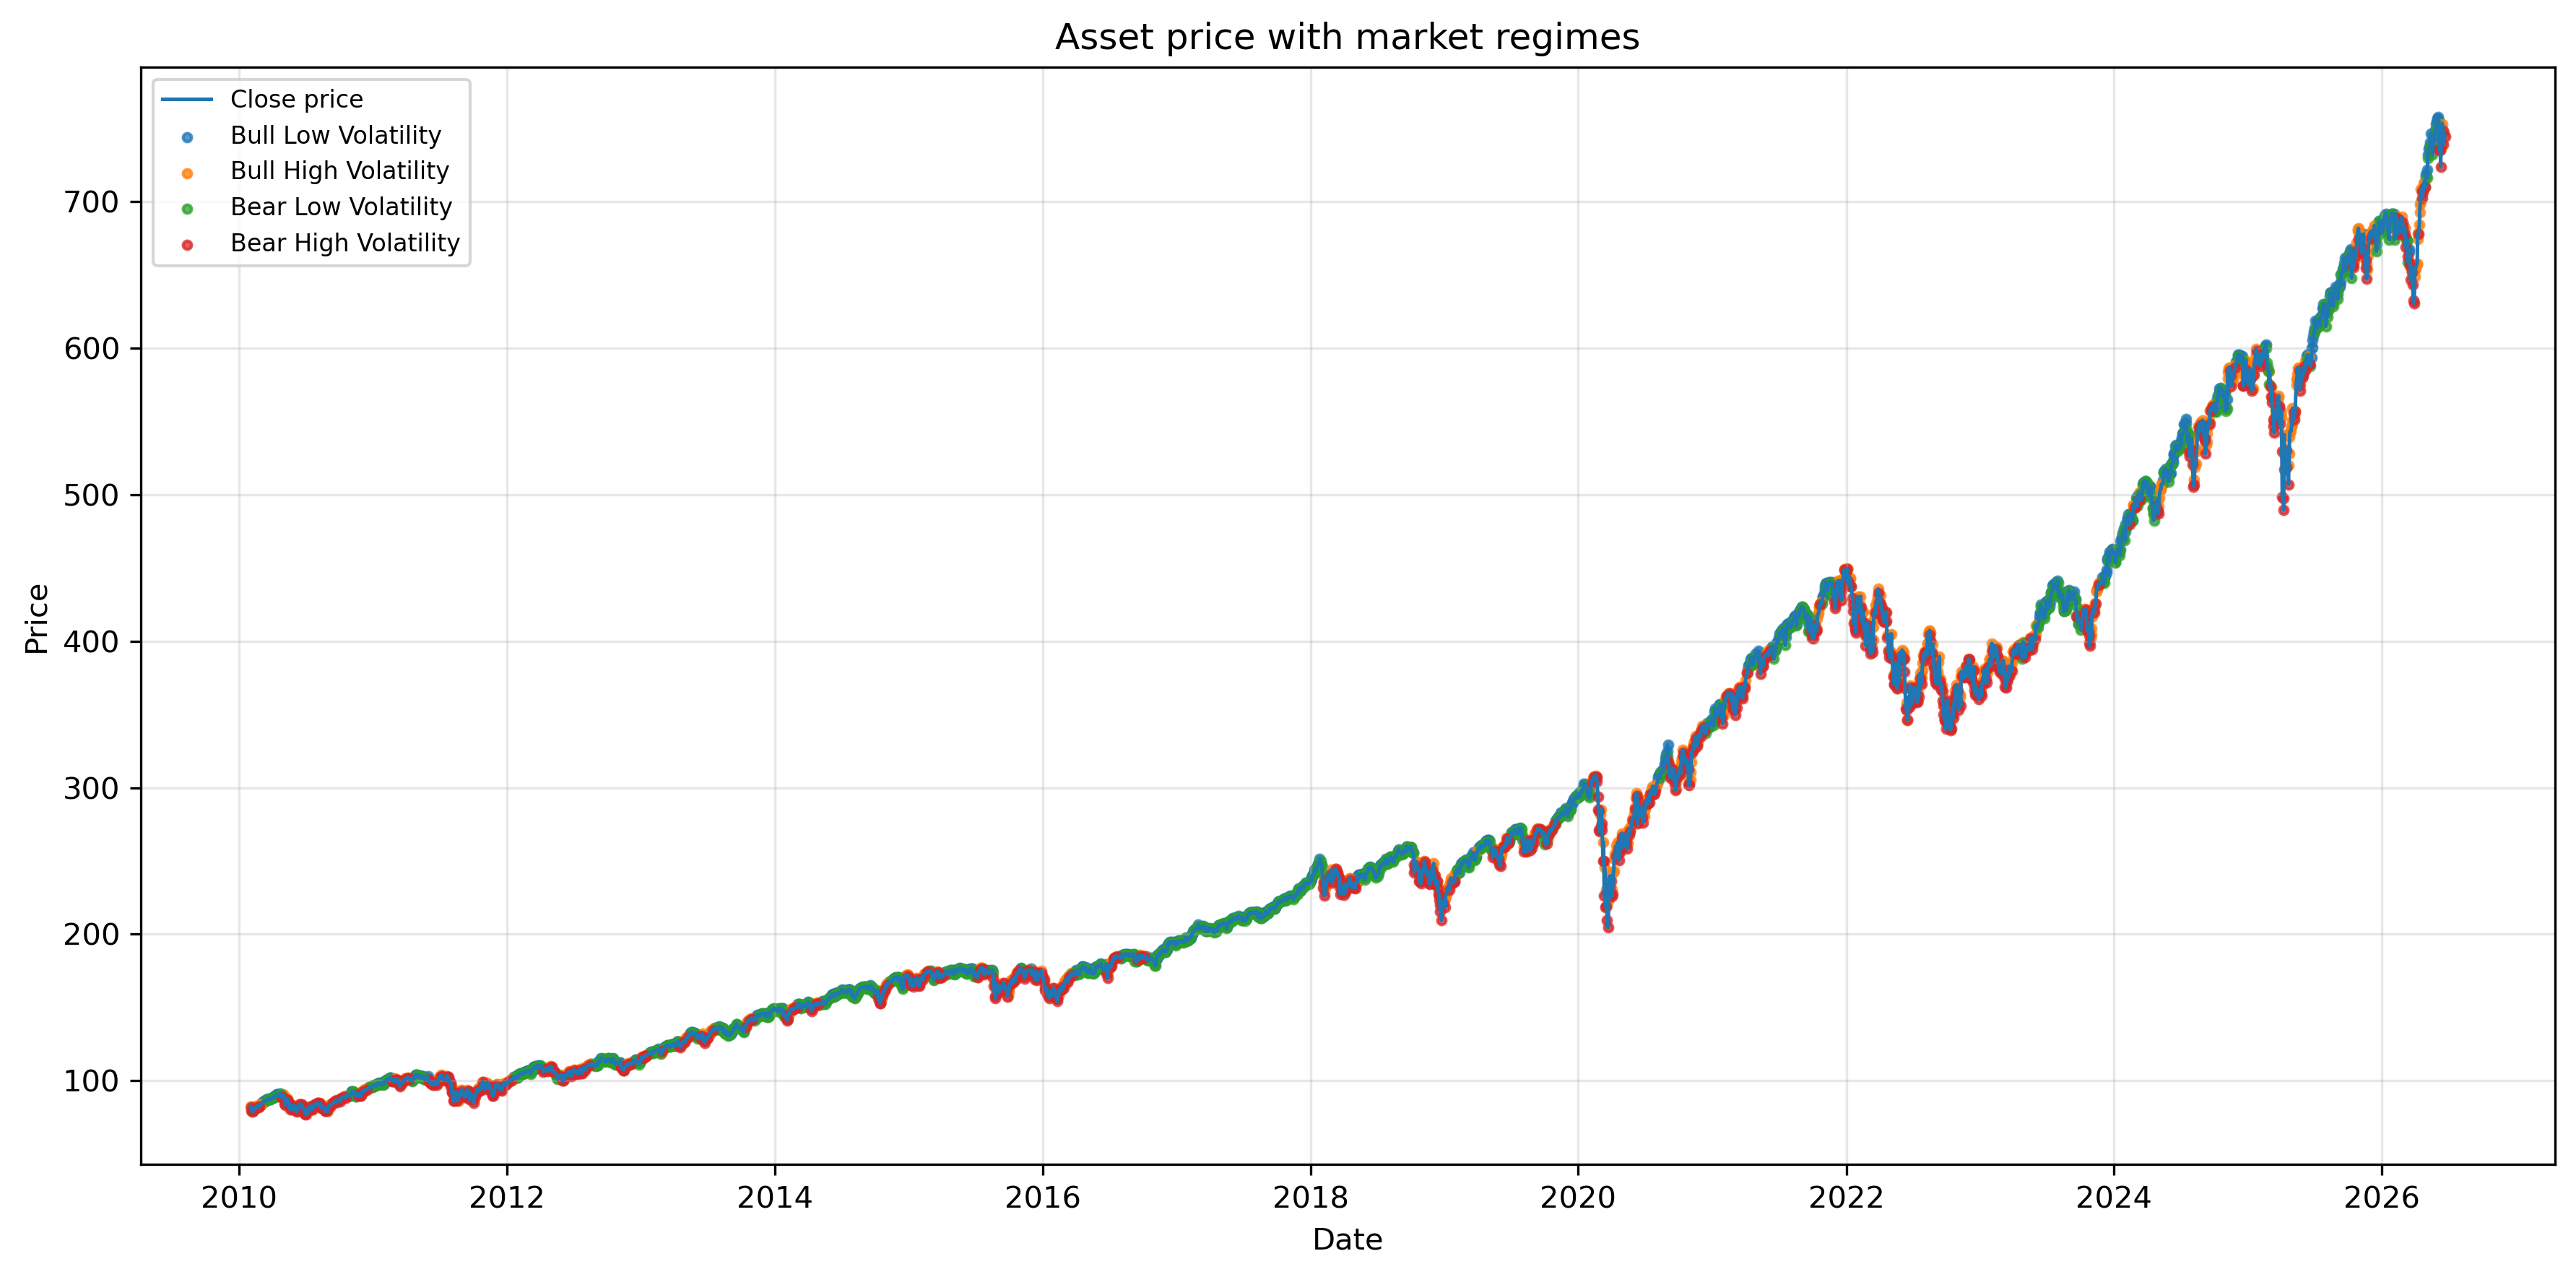


volatility_threshold.png


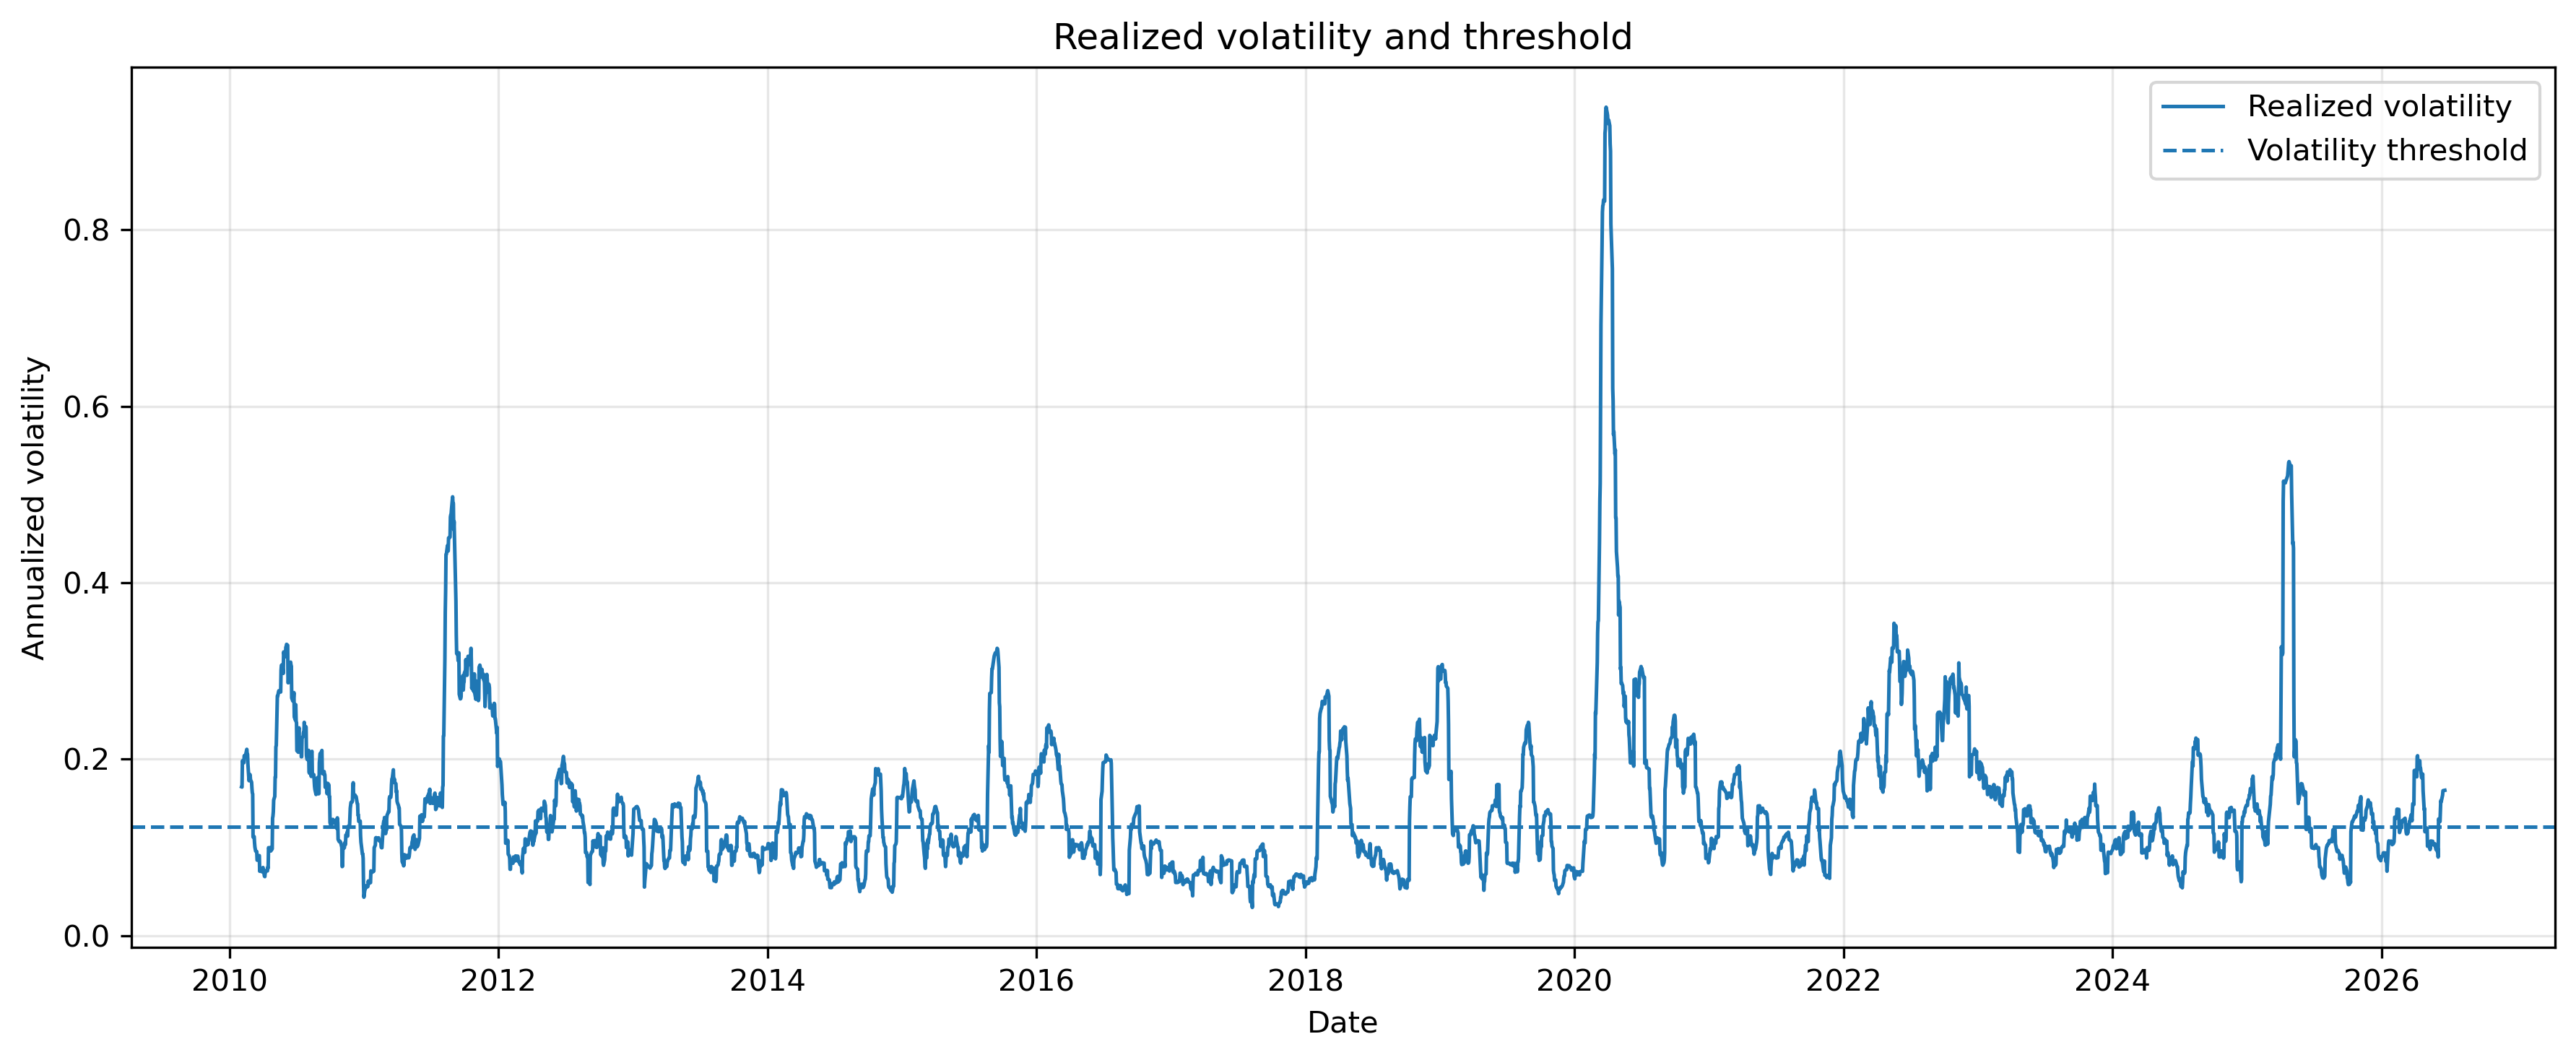


transition_matrix_heatmap.png


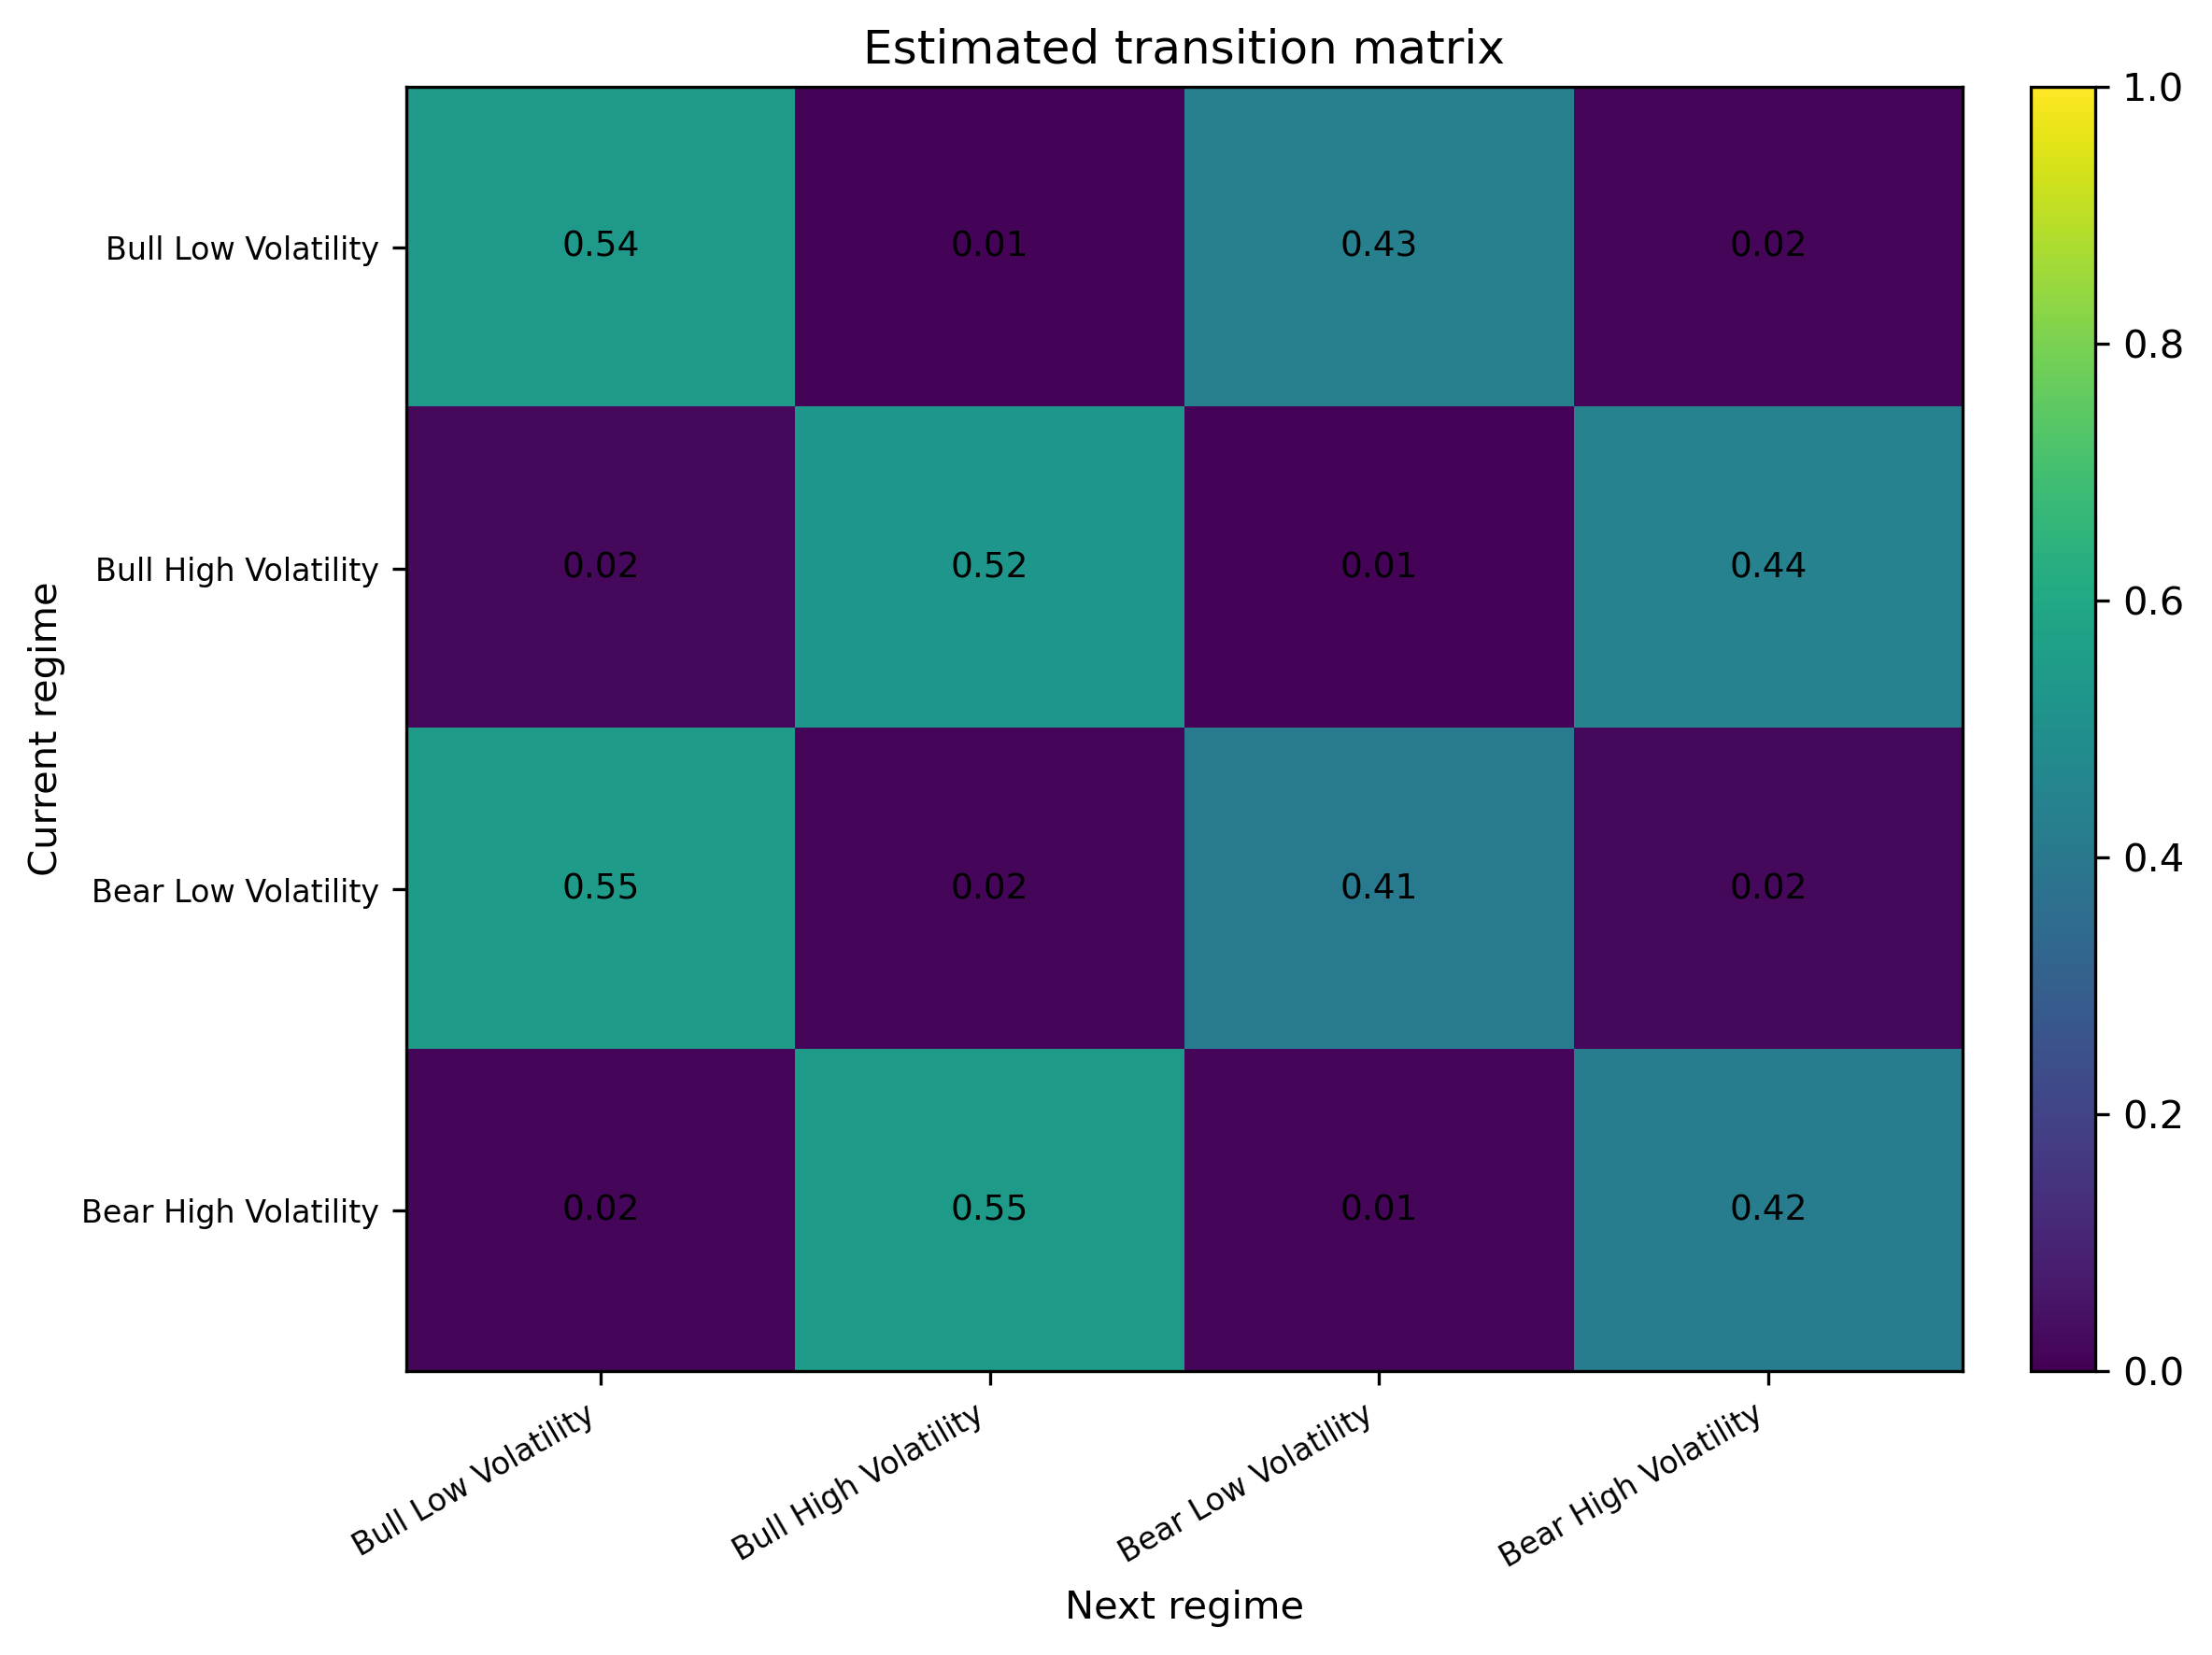


strategy_vs_benchmark.png


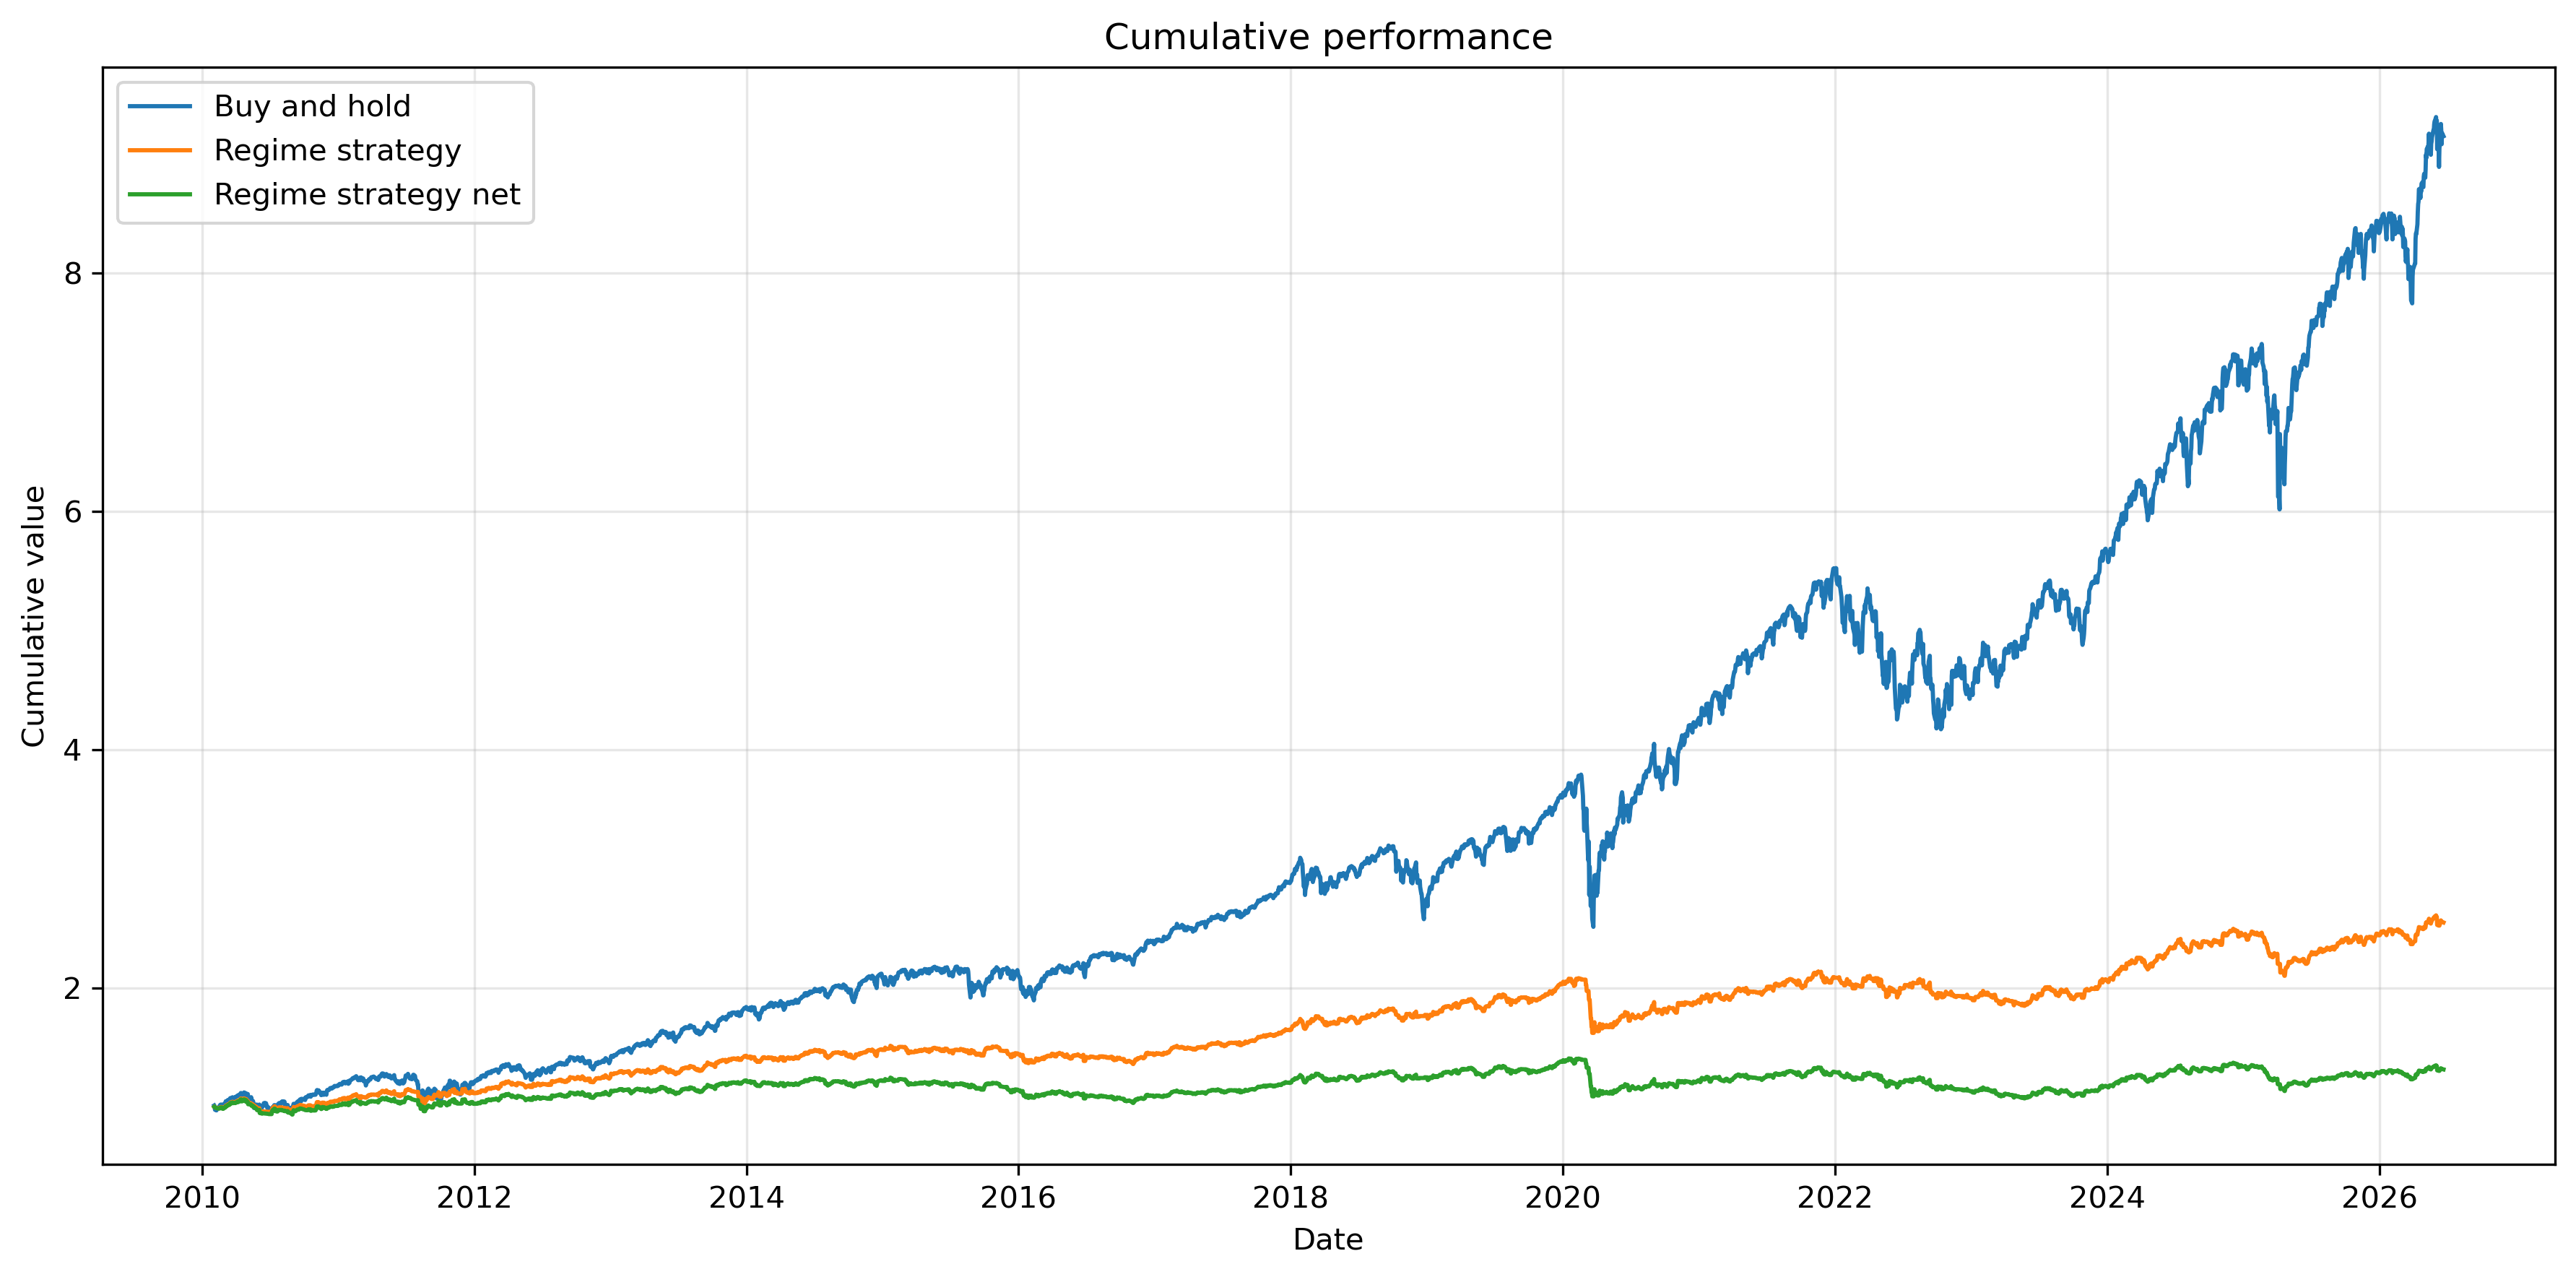


drawdown_comparison.png


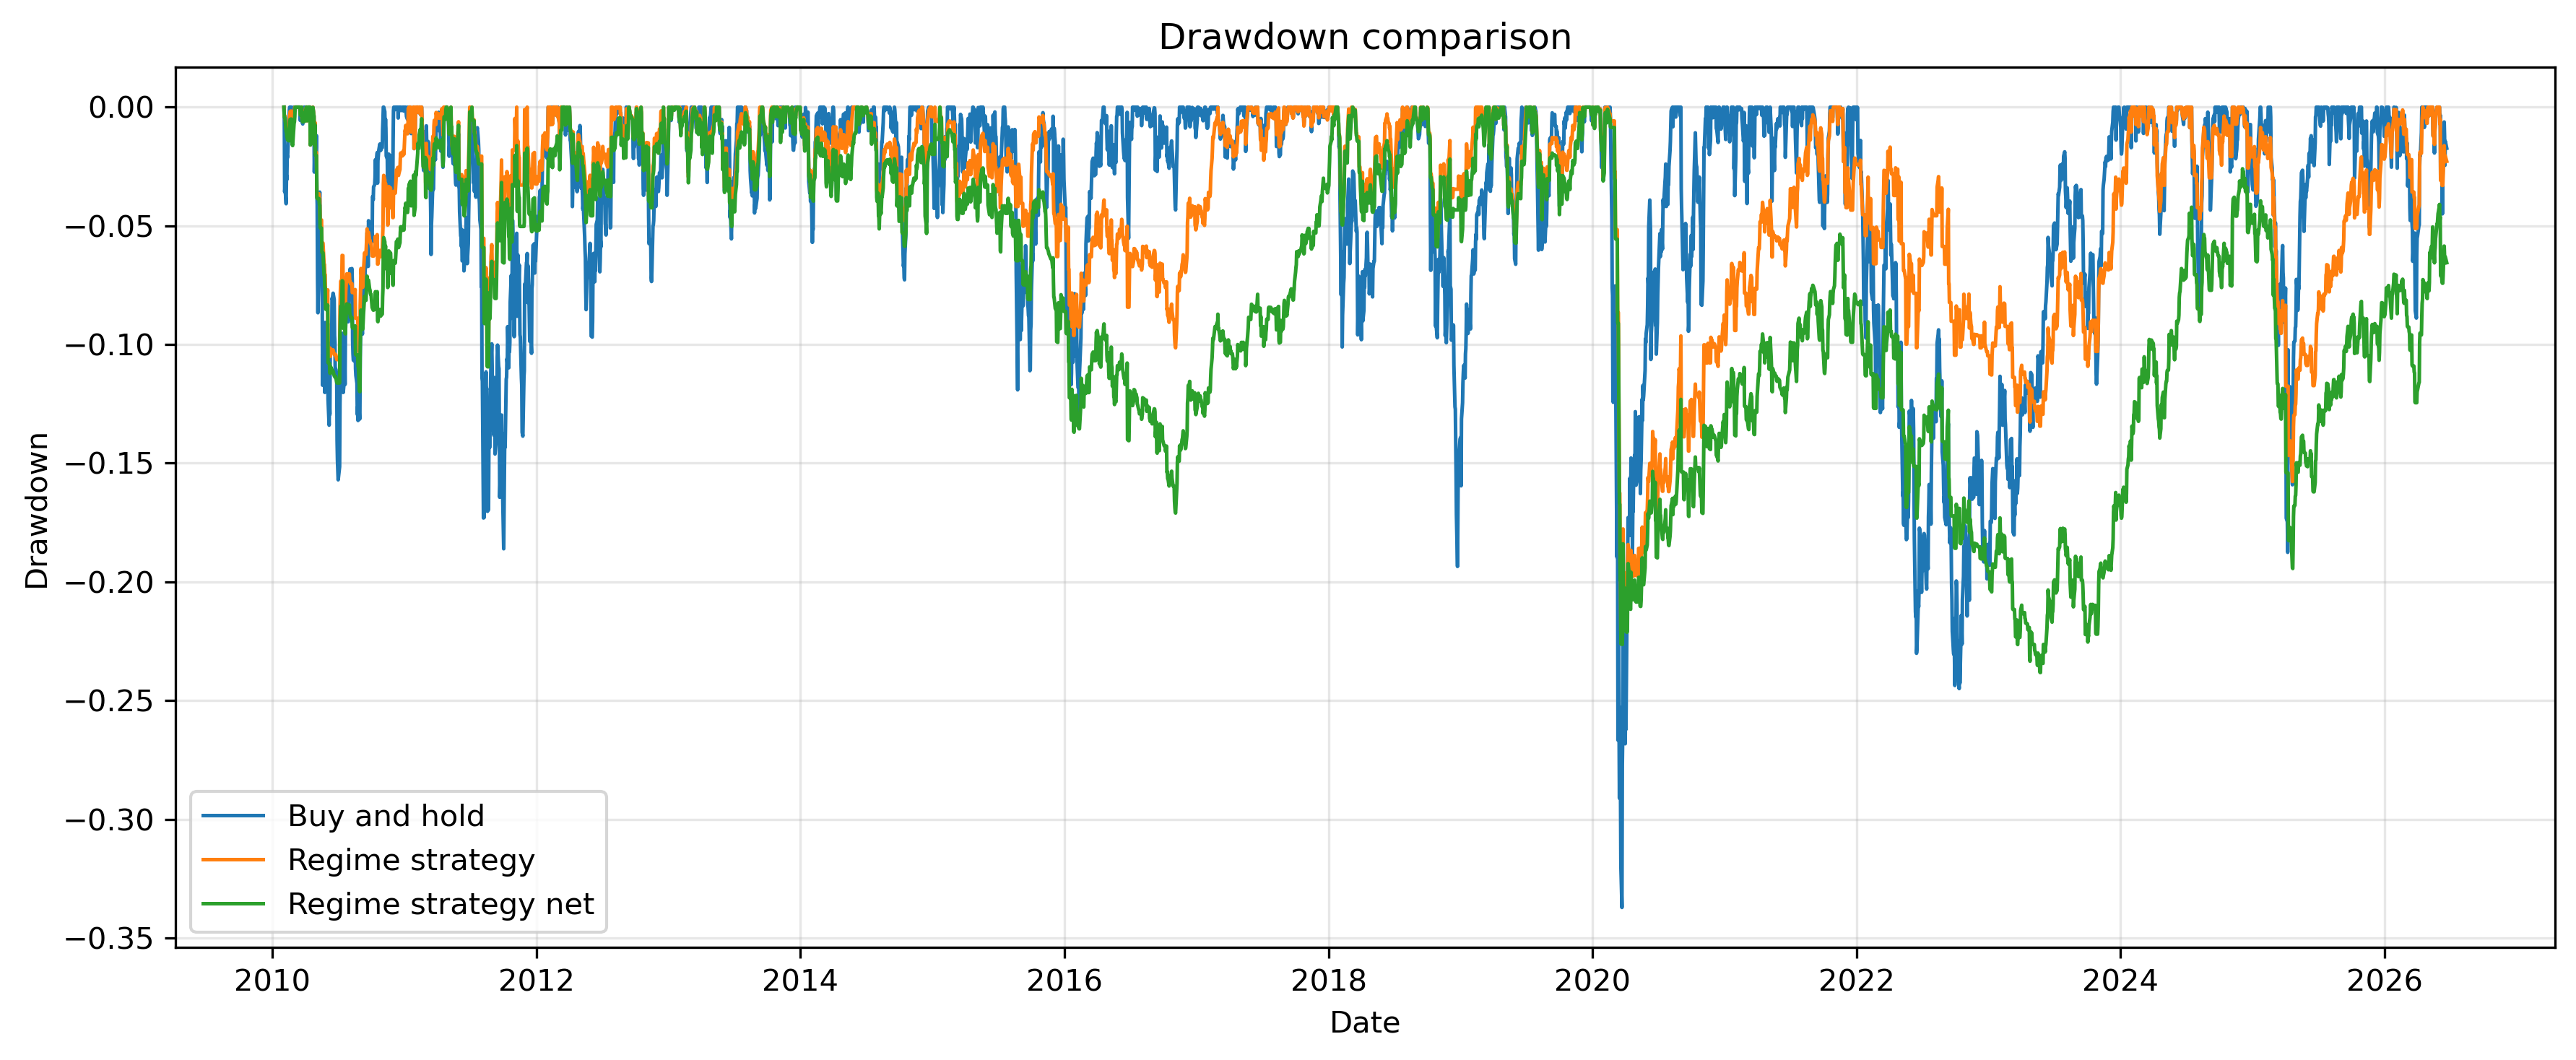

In [16]:
figure_files = [
    "regimes_over_time.png",
    "volatility_threshold.png",
    "transition_matrix_heatmap.png",
    "strategy_vs_benchmark.png",
    "drawdown_comparison.png",
]

for filename in figure_files:
    path = FIGURES_DIR / filename
    print(f"\n{filename}")
    display(Image(filename=str(path)))

## 7. Interpretation

The transition matrix provides a compact summary of regime persistence. Diagonal coefficients measure the probability of remaining in the same regime from one day to the next.

The expected duration of each regime is derived from this persistence. If a regime has a high diagonal transition probability, it tends to last longer.

The backtest compares a buy-and-hold benchmark with a simple regime-based allocation strategy. The objective is not necessarily to maximize raw return, but to evaluate whether reducing exposure during unfavorable regimes can improve risk-adjusted performance or reduce drawdowns.

The strategy is intentionally simple and should be interpreted as a baseline rather than a production-ready trading rule.

## 8. Limitations and Extensions

This project is intentionally simple and interpretable. Several extensions are natural:

- estimate transition matrices on rolling windows;
- use quantile-based or adaptive volatility thresholds;
- compare the Markov model with higher-order Markov chains;
- define regimes using clustering methods;
- implement a Hidden Markov Model;
- estimate regime-conditional expected returns and variances;
- derive the allocation rule from a mean-variance or utility maximization problem;
- add more realistic transaction costs, slippage, and cash returns.

The current framework should be viewed as a transparent baseline connecting probability theory, financial time series, and dynamic allocation.